# Project Objectives

The goal of this project is to perform data cleaning, preprocessing, exploratory analysis, and business-oriented insights generation using the Airbnb listings dataset. The project focuses on transforming raw and inconsistent data into a structured dataset suitable for analysis while identifying patterns related to pricing, demand, and listing performance.

## Objectives

### 1. Data Cleaning and Preprocessing

Prepare the dataset for reliable analysis by handling:

* Missing values
* Duplicate records
* Inconsistent categorical values
* Outliers and abnormal values
* Incorrect formatting and data quality issues

This step ensures the dataset is accurate, consistent, and suitable for further analytical tasks.

---

### 2. Revenue Estimation Analysis

Investigate which listing characteristics are most associated with higher estimated revenue using indicators such as:

* Price
* Availability
* Review activity
* Room type
* Neighborhood

This analysis helps identify which factors contribute most to revenue potential rather than simply high listing prices.

---

### 3. Location-Based Investment Analysis

Analyze neighborhoods and geographic trends to determine which locations demonstrate stronger market performance in terms of:

* Pricing
* Demand
* Review frequency
* Availability patterns

The objective is to identify areas with high investment potential for future Airbnb listings.

---

### 4. Demand Driver Analysis

Examine which listing features are associated with higher customer demand using metrics such as:

* Number of reviews
* Reviews per month
* Availability trends

This helps identify the characteristics that may contribute to increased bookings and customer engagement.

---

### 5. Listing Optimization Analysis

Evaluate how listing characteristics and amenities influence overall listing performance.

This includes analyzing factors such as:

* Room type
* Minimum nights
* Availability
* Review metrics
* Host-related attributes

The objective is to determine which listing improvements may positively impact performance.

---

### 6. Market Segmentation Analysis

Compare pricing behavior and demand across different property categories, including:

* Entire homes/apartments
* Private rooms
* Shared rooms

This analysis helps understand how different market segments perform under varying conditions.

---

### 7. Exploratory Data Analysis and Visualization

Use statistical summaries and visualizations to uncover:

* Pricing distributions
* Demand patterns
* Neighborhood trends
* Correlations between variables
* Market behavior insights

The goal is to transform raw data into meaningful business and analytical insights through visual and statistical exploration.


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data= pd.read_csv('/Airbnb_Open_Data.csv', engine='python')

In [ ]:
data.shape

(102599, 26)

In [ ]:
data.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [ ]:
list(data.columns)

['id',
 'NAME',
 'host id',
 'host_identity_verified',
 'host name',
 'neighbourhood group',
 'neighbourhood',
 'lat',
 'long',
 'country',
 'country code',
 'instant_bookable',
 'cancellation_policy',
 'room type',
 'Construction year',
 'price',
 'service fee',
 'minimum nights',
 'number of reviews',
 'last review',
 'reviews per month',
 'review rate number',
 'calculated host listings count',
 'availability 365',
 'house_rules',
 'license']

In [ ]:

# Create documentation mapping each column to its meaning for reference
# This helps understand the data and communicate findings to stakeholders

cols=['id',
 'NAME',
 'host id',
 'host_identity_verified',
 'host name',
 'neighbourhood group',
 'neighbourhood',
 'lat',
 'long',
 'country',
 'country code',
 'instant_bookable',
 'cancellation_policy',
 'room type',
 'Construction year',
 'price',
 'service fee',
 'minimum nights',
 'number of reviews',
 'last review',
 'reviews per month',
 'review rate number',
 'calculated host listings count',
 'availability 365',
 'house_rules',
 'license']

col_meaning=[

'Unique identifier for each listing',
'Title of the Airbnb listing shown to users',
'Unique identifier for the host',
'Indicates whether Airbnb has verified the host’s identity (True/False)',
' Name of the host managing the property.',
'Broad area or district where the listing is located (e.g., borough or city region).',
'More specific local area within the neighbourhood group.',
'Latitude coordinate of the property; used for mapping location.',
'Longitude coordinate of the property; used with latitude for exact location.',
'Country where the listing is located.',
' Short code for the country',
'Indicates if the property can be booked immediately without host approval (True/False)',
'Rules defining how flexible or strict cancellations are.',
'Type of space offered (entire home, private room, shared room).',
'Year the property was built; gives an idea of property age.',
'Cost per night for renting the listing.',
'Additional fee charged by the platform on top of the price.',
'Minimum number of nights a guest must book.',
'Total count of reviews received for the listing.',
'Date when the most recent review was posted.',
'Average number of reviews received each month.',
'Average rating score given by guests.',
'Number of active listings managed by the host.',
'Number of days the listing is available in a year.',
'Text describing rules guests must follow during their stay.',
'Official registration or license number of the property (if required).'

]

In [ ]:
pd.DataFrame(list(zip(cols, col_meaning)), columns=['column','meaning'])

,column,meaning
0,id,Unique identifier for each listing
1,NAME,Title of the Airbnb listing shown to users
2,host id,Unique identifier for the host
3,host_identity_verified,Indicates whether Airbnb has verified the host...
4,host name,Name of the host managing the property.
5,neighbourhood group,Broad area or district where the listing is lo...
6,neighbourhood,More specific local area within the neighbourh...
7,lat,Latitude coordinate of the property; used for ...
8,long,Longitude coordinate of the property; used wit...
9,country,Country where the listing is located.


In [ ]:
data.isnull().sum().sort_values()

,0
id,0
host id,0
room type,0
lat,8
long,8
neighbourhood,16
neighbourhood group,29
cancellation_policy,76
instant_bookable,105
country code,131


In [ ]:
data.describe()

,id,host id,lat,long,Construction year,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
count,1.025990e+05,1.025990e+05,102591.000000,102591.000000,102385.000000,102190.000000,102416.000000,86720.000000,102273.000000,102280.000000,102151.000000
mean,2.914623e+07,4.925411e+10,40.728094,-73.949644,2012.487464,8.135845,27.483743,1.374022,3.279106,7.936605,141.133254
std,1.625751e+07,2.853900e+10,0.055857,0.049521,5.765556,30.553781,49.508954,1.746621,1.284657,32.218780,135.435024
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,-1223.000000,0.000000,0.010000,1.000000,1.000000,-10.000000
25%,1.508581e+07,2.458333e+10,40.688740,-73.982580,2007.000000,2.000000,1.000000,0.220000,2.000000,1.000000,3.000000
50%,2.913660e+07,4.911774e+10,40.722290,-73.954440,2012.000000,3.000000,7.000000,0.740000,3.000000,1.000000,96.000000
75%,4.320120e+07,7.399650e+10,40.762760,-73.932350,2017.000000,5.000000,30.000000,2.000000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,5645.000000,1024.000000,90.000000,5.000000,332.000000,3677.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [ ]:
data.dtypes

,0
id,int64
NAME,object
host id,int64
host_identity_verified,object
host name,object
neighbourhood group,object
neighbourhood,object
lat,float64
long,float64
country,object


In [ ]:

# Remove columns that don't contribute to analysis:
# - id, host id: Unique identifiers (no analytical value)
# - NAME, host name: Free text fields (inconsistent, hard to standardize)
# - country, country code: All listings in US (no variation to analyze)
data.drop(columns=['id','host id','NAME','host name','country','country code'],inplace=True)

In [ ]:
data.head()

,host_identity_verified,neighbourhood group,neighbourhood,lat,long,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,unconfirmed,Brooklyn,Kensington,40.64749,-73.97237,False,strict,Private room,2020.0,$966,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,verified,Manhattan,Midtown,40.75362,-73.98377,False,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,NaN,Manhattan,Harlem,40.80902,-73.94190,True,flexible,Private room,2005.0,$620,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,unconfirmed,Brooklyn,Clinton Hill,40.68514,-73.95976,True,moderate,Entire home/apt,2005.0,$368,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,verified,Manhattan,East Harlem,40.79851,-73.94399,False,moderate,Entire home/apt,2009.0,$204,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [ ]:
# fixing inconsistant format

In [ ]:
data['neighbourhood group'].unique()

array(['Brooklyn', 'Manhattan', 'brookln', 'manhatan', 'Queens', nan,
       'Staten Island', 'Bronx'], dtype=object)

In [ ]:
data['neighbourhood group'] = data['neighbourhood group'].replace({
    'brookln': 'Brooklyn',
    'manhatan': 'Manhattan'
})

In [ ]:
data['neighbourhood group'].unique()

array(['Brooklyn', 'Manhattan', 'Queens', nan, 'Staten Island', 'Bronx'],
      dtype=object)

In [ ]:
data['price']

,price
0,$966
1,$142
2,$620
3,$368
4,$204
...,...
102594,$844
102595,$837
102596,$988
102597,$546


In [ ]:
data["price"] = (
    data["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(" ", "", regex=False)
)

In [ ]:

data["price"] = pd.to_numeric(data["price"], errors="coerce")

In [ ]:
data['service fee'].sample()   # how it looks before fixing format

,service fee
81629,$75


In [ ]:
data["service fee"] = (
    data["service fee"]
    .str.replace("%", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False))



In [ ]:
data["service fee"] = pd.to_numeric(data["service fee"], errors="coerce")

In [ ]:
data['service fee'].sample()   # how it looks after fixing format

,service fee
15965,126.0


In [ ]:
# removing wrong entries:

In [ ]:
(data['minimum nights'] < 0).sum()    #since there are wrong entries and they are clearly wrong entries i'll drop them

np.int64(13)

In [ ]:
data = data[data['minimum nights'] >= 0]

In [ ]:

(data['minimum nights'] < 0).sum()

np.int64(0)

In [ ]:
(data['availability 365']<0).sum()

np.int64(426)

In [ ]:
(data['availability 365']>365).sum()

np.int64(2765)

In [ ]:
data = data[data['availability 365'] >= 0]

In [ ]:
'''
I identified approximately 2,700 rows where availability_365 exceeded its theoretical maximum of 365.
 Since this variable is strictly bounded between 0 and 365, these values represent data quality issues rather than valid extreme observations.
Removing these rows would result in a loss of nearly 3% of the dataset, which could negatively impact downstream analysis.
To preserve the observations while enforcing the logical constraint of the feature, I applied capping at 365 using a clipping approach.
'''
data['availability 365'] = np.where(data['availability 365'] > 365, 365, data['availability 365']) #capping to upper values

In [ ]:
(data['availability 365']>365).sum()

np.int64(0)

In [ ]:
# handling duplicate values

In [ ]:
data.duplicated().sum()

np.int64(3439)

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
data.duplicated().sum()    #removed duplicated values

np.int64(0)

In [ ]:
# handling missing values

In [ ]:
(data.isna().sum() / len(data) * 100).sort_values(ascending=False)


,0
license,99.997957
house_rules,51.300492
last review,15.295344
reviews per month,15.295344
calculated host listings count,0.311587
review rate number,0.293198
service fee,0.276853
host_identity_verified,0.274809
price,0.251313
Construction year,0.187974


In [ ]:
'''
The license column had over 99.99% missing values — only 2 listings out of 102,000 had license information.
At that level of sparsity, the column provides no actionable signal, so I dropped it entirely
'''

data.drop(columns=['license'],inplace=True)

In [ ]:
'''# Convert house_rules to binary feature
# Instead of dropping (which would lose >50% of data), create indicator for presence
# This preserves information about whether a listing HAS rules, without the text content'''

data["has_house_rules"] = data["house_rules"].notnull().astype(int)

In [ ]:
data.drop(columns=['house_rules'],inplace=True)

In [ ]:
data.head(2)

,host_identity_verified,neighbourhood group,neighbourhood,lat,long,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,has_house_rules
0,unconfirmed,Brooklyn,Kensington,40.64749,-73.97237,False,strict,Private room,2020.0,966.0,193.0,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,1
1,verified,Manhattan,Midtown,40.75362,-73.98377,False,moderate,Entire home/apt,2007.0,142.0,28.0,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,1


In [ ]:
data["number of reviews"] = data["number of reviews"].fillna(0)    #if theres smth missing then theres no reviews

In [ ]:
#Fill with 0 only if 'number of reviews' is 0
data['reviews per month'] = np.where(
    (data['reviews per month'].isna()) & (data['number of reviews'] == 0),
    0,
    data['reviews per month']
)

# For any remaining NaNs (where reviews > 0 but rate is missing), use the median
remaining_median = data['reviews per month'].median()
data['reviews per month'] = data['reviews per month'].fillna(remaining_median)

In [ ]:
data["last review"] = pd.to_datetime(data["last review"], errors="coerce")     #instead of having plain time i can converted to how many days since the last review


In [ ]:
data['last review'] = data['last review'].fillna('NaT')

In [ ]:

''' Convert last review date to days since last review (more useful for analysis)
 Reference date: 2022-09-11 (approximate date when dataset was collected)'''

reference_date = pd.Timestamp("2022-09-11")
data["days_since_last_review"] = (reference_date - data["last review"]).dt.days
data.drop(columns=["last review"], inplace=True)

In [ ]:
data['days_since_last_review']=data['days_since_last_review'].fillna(data['days_since_last_review'].median())

In [ ]:
# Drop rows missing location coordinates
# Only 8 rows affected - minimal data loss for cleaner geospatial analysis

data.dropna(subset=['lat', 'long'], inplace=True)

In [ ]:
# Impute remaining missing values:
# - Categorical columns: mode imputation (most frequent value)
# - Numeric columns: median imputation (robust to outliers)


In [ ]:
data["neighbourhood"] = data["neighbourhood"].fillna(data["neighbourhood"].mode()[0])    #since its an object feature
data["neighbourhood group"] = data["neighbourhood group"].fillna(data["neighbourhood group"].mode()[0])

In [ ]:
data["instant_bookable"] = data["instant_bookable"].fillna(data["instant_bookable"].mode()[0])

/tmp/ipykernel_3516/431655389.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["instant_bookable"] = data["instant_bookable"].fillna(data["instant_bookable"].mode()[0])


In [ ]:
data["cancellation_policy"] = data["cancellation_policy"].fillna(data["cancellation_policy"].mode()[0])

In [ ]:
data["price"] = data["price"].fillna(data["price"].median())

In [ ]:

data["service fee"] = data["service fee"].fillna(data["service fee"].median())

In [ ]:
data['minimum nights']=data['minimum nights'].fillna(data['minimum nights'].median())

In [ ]:
data["review rate number"] = data["review rate number"].fillna(data["review rate number"].median())

In [ ]:
data["calculated host listings count"] = data["calculated host listings count"].fillna(data["calculated host listings count"].median())

In [ ]:
data["availability 365"] = data["availability 365"].fillna(data["availability 365"].median())

In [ ]:
data["host_identity_verified"] = data["host_identity_verified"].fillna(data["host_identity_verified"].mode()[0])

In [ ]:
data['Construction year'] = pd.to_numeric(data['Construction year'], errors='coerce')

In [ ]:
data["Construction year"] = data["Construction year"].fillna(data["Construction year"].median())

In [ ]:
data.isnull().sum()



,0
host_identity_verified,0
neighbourhood group,0
neighbourhood,0
lat,0
long,0
instant_bookable,0
cancellation_policy,0
room type,0
Construction year,0
price,0


In [ ]:
#handling outliers & feature engineering

In [ ]:
# Create stay_category from minimum nights for easier interpretation
# Categories: Short-stay (1-3), Weekly (4-7), Monthly (8-30), Long-term (30+)

bins = [0, 3, 7, 30, 365]
labels = ['Short-stay (1-3 nights)', 'Weekly (4-7)', 'Monthly (8-30)', 'Long-term (30+)']
data['stay_category'] = pd.cut(data['minimum nights'], bins=bins, labels=labels)

In [ ]:
data.sample()

,host_identity_verified,neighbourhood group,neighbourhood,lat,long,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365,has_house_rules,days_since_last_review,stay_category
38943,unconfirmed,Brooklyn,Bedford-Stuyvesant,40.68726,-73.93289,True,flexible,Private room,2019.0,1105.0,221.0,30.0,0.0,0.0,3.0,27.0,312.0,0,1185.0,Monthly (8-30)


In [ ]:
data['stay_category'].value_counts()

,count
stay_category,
Short-stay (1-3 nights),62375
Weekly (4-7),17415
Monthly (8-30),16457
Long-term (30+),1598


In [ ]:
# outliers in this data set usually represent real rare events like price for some niche apt so we keep them ,
# added a new feature for log transformed the price for easy visualisation



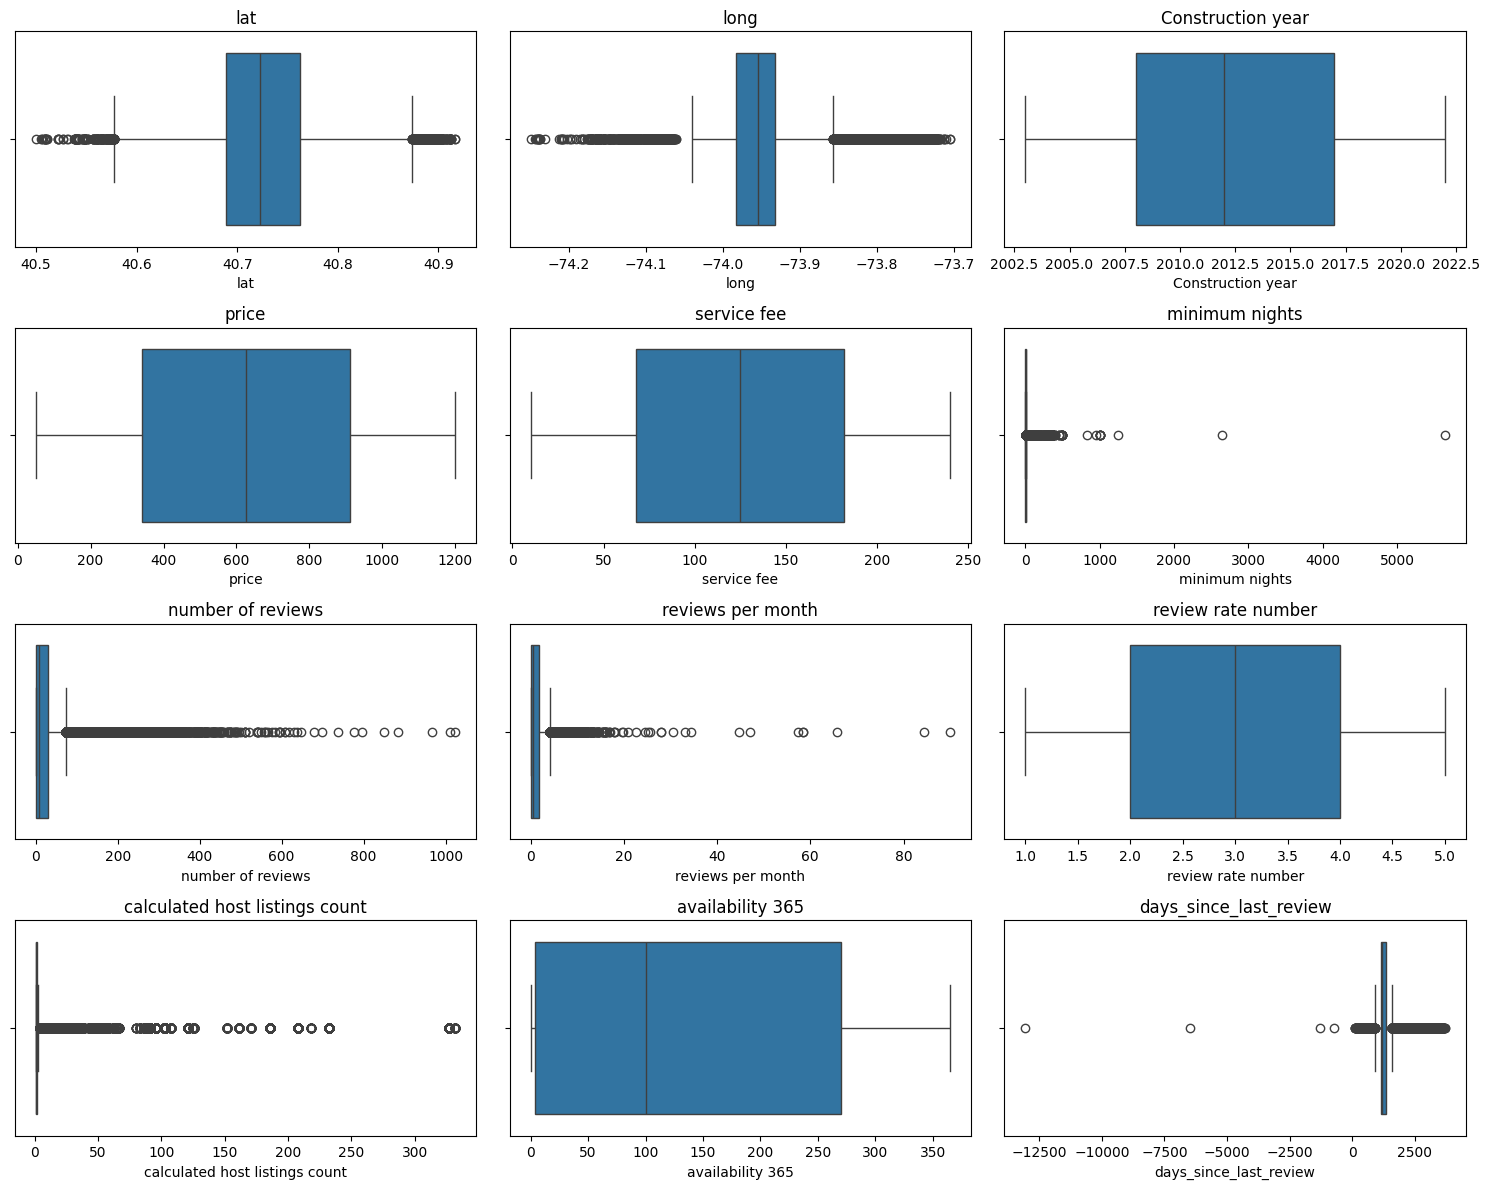

In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = ['lat', 'long', 'Construction year', 'price', 'service fee',
            'minimum nights', 'number of reviews', 'reviews per month',
            'review rate number', 'calculated host listings count',
            'availability 365', 'days_since_last_review']


cols_per_row = 3
rows = math.ceil(len(num_cols) / cols_per_row)

plt.figure(figsize=(cols_per_row * 5, rows * 3))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.tight_layout()

plt.show()

In [ ]:
# Remove impossible negative time values
data = data[data['days_since_last_review'] >0]
data['days_since_last_review'] = data['days_since_last_review'].clip(upper=2000)

In [ ]:
# feature engineering :
# Create listing_status based on recency of last review
# Recently Active: ≤1 year, Stale: 1-3 years, Inactive: >3 years

def categorize_activity(days):
    if days <= 365:
        return 'Recently Active'
    elif days <= 1095:
        return 'Stale (1-3 years)'
    else:
        return 'Inactive'

# 2. Create the new column
data['listing_status'] = data['days_since_last_review'].apply(categorize_activity)

# 3. Quick check of the distribution
print(data['listing_status'].value_counts())

listing_status
Inactive             78994
Recently Active      14505
Stale (1-3 years)     4375
Name: count, dtype: int64


In [ ]:
# Bounding box for NYC (based on  lat/long plots)
data = data[data['lat'].between(40.5, 40.95) & data['long'].between(-74.3, -73.7)]

In [ ]:
# Cap minimum nights to 1 year (removes the 5000+ nights outlier)
data['minimum nights'] = data['minimum nights'].clip(upper=365)

In [ ]:
# Use Log(x+1) for the columns with extreme right-skew tails
# didnt remove the raw features since its easier to disscus for audiance and added a log transformation for correlations
skewed_cols = ['number of reviews', 'reviews per month', 'calculated host listings count']
for col in skewed_cols:
    data[f'{col}_log'] = np.log1p(data[col])

In [ ]:
data.head()

,host_identity_verified,neighbourhood group,neighbourhood,lat,long,instant_bookable,cancellation_policy,room type,Construction year,price,...,review rate number,calculated host listings count,availability 365,has_house_rules,days_since_last_review,stay_category,listing_status,number of reviews_log,reviews per month_log,calculated host listings count_log
0,unconfirmed,Brooklyn,Kensington,40.64749,-73.97237,False,strict,Private room,2020.0,966.0,...,4.0,6.0,286.0,1,327.0,Monthly (8-30),Recently Active,2.302585,0.190620,1.945910
1,verified,Manhattan,Midtown,40.75362,-73.98377,False,moderate,Entire home/apt,2007.0,142.0,...,4.0,2.0,228.0,1,113.0,Monthly (8-30),Recently Active,3.828641,0.322083,1.098612
2,unconfirmed,Manhattan,Harlem,40.80902,-73.94190,True,flexible,Private room,2005.0,620.0,...,5.0,1.0,352.0,1,1185.0,Short-stay (1-3 nights),Inactive,0.000000,0.000000,0.693147
3,unconfirmed,Brooklyn,Clinton Hill,40.68514,-73.95976,True,moderate,Entire home/apt,2005.0,368.0,...,4.0,1.0,322.0,0,1164.0,Monthly (8-30),Inactive,5.602119,1.729884,0.693147
4,verified,Manhattan,East Harlem,40.79851,-73.94399,False,moderate,Entire home/apt,2009.0,204.0,...,3.0,1.0,289.0,1,1392.0,Monthly (8-30),Inactive,2.302585,0.095310,0.693147


In [ ]:
data.shape

(97873, 24)

In [ ]:
data['est_monthly_revenue'] = data['price'] * data['reviews per month']
data['popularity_score'] = data['reviews per month'] * data['review rate number']
data['listing_age'] = 2022 - data['Construction year']

In [ ]:
# 1. Revenue Estimation: Correlation Matrix
# Which factors most strongly influence expected revenue?
revenue_factors_list = ['est_monthly_revenue', 'price', 'reviews per month',
                        'review rate number', 'minimum nights', 'listing_age', 'service fee']

revenue_correlation = data[revenue_factors_list].corr()

print("--- Revenue Estimation: Correlation Matrix ---")
# Sorting by revenue to see the strongest drivers at the top
print(revenue_correlation['est_monthly_revenue'].sort_values(ascending=False))

--- Revenue Estimation: Correlation Matrix ---
est_monthly_revenue    1.000000
reviews per month      0.833944
price                  0.314511
service fee            0.313782
review rate number     0.025393
listing_age           -0.001721
minimum nights        -0.130985
Name: est_monthly_revenue, dtype: float64


In [ ]:
# location analysis
#avg revenue by neighbourhood group
location_analysis = data.groupby('neighbourhood group')['est_monthly_revenue'].mean().sort_values(ascending=False)
print("\n--- Revenue by Neighbourhood Group ---")
print(location_analysis)
#Top 10 specific neighbourhoods for investment
top_neighborhoods = data.groupby('neighbourhood')['est_monthly_revenue'].mean().sort_values(ascending=False).head(10)
print("\n--- Top 10 Neighbourhoods by Revenue ---")
print(top_neighborhoods)


--- Revenue by Neighbourhood Group ---
neighbourhood group
Staten Island    1010.787365
Queens           1006.340034
Bronx             945.245378
Brooklyn          712.046339
Manhattan         650.372845
Name: est_monthly_revenue, dtype: float64

--- Top 10 Neighbourhoods by Revenue ---
neighbourhood
Chelsea, Staten Island    3230.200000
Huguenot                  2938.056667
East Elmhurst             2739.005767
Springfield Gardens       2276.079959
Glen Oaks                 2232.750000
Silver Lake               2140.865556
Gerritsen Beach           2109.466667
New Brighton              1915.241333
East Morrisania           1846.607143
Schuylerville             1834.768913
Name: est_monthly_revenue, dtype: float64


In [ ]:
#Demand analysis: How minimum stay requirements affect booking frequency
demand_by_nights = data.groupby('minimum nights')['reviews per month'].mean().head(20)
print("\n--- Demand by Minimum Nights ---")
print(demand_by_nights)
#Policy analysis: Impact of cancellation policy on demand
demand_by_cancellation = data.groupby('cancellation_policy')['reviews per month'].mean()
print("\n--- Demand by Cancellation Policy ---")
print(demand_by_cancellation)


--- Demand by Minimum Nights ---
minimum nights
1.0     1.784914
2.0     1.490666
3.0     1.120883
4.0     0.905557
5.0     0.705164
6.0     0.613610
7.0     0.442333
8.0     0.392704
9.0     0.386463
10.0    0.333826
11.0    0.457407
12.0    0.304088
13.0    0.377755
14.0    0.363385
15.0    0.328179
16.0    0.317059
17.0    0.233182
18.0    0.395833
19.0    0.127059
20.0    0.322548
Name: reviews per month, dtype: float64

--- Demand by Cancellation Policy ---
cancellation_policy
flexible    1.173263
moderate    1.171734
strict      1.155315
Name: reviews per month, dtype: float64


In [ ]:
# Listing Optimization
# Impact of Instant Booking on expected revenue
instant_book_impact = data.groupby('instant_bookable')['est_monthly_revenue'].mean()
print("\n--- Instant Booking Impact on Revenue ---")
print(instant_book_impact)
#Impact of Review Rating (Stars) on expected revenue
rating_impact = data.groupby('review rate number')['est_monthly_revenue'].mean()
print("\n--- Review Rating Impact on Revenue ---")
print(rating_impact)


--- Instant Booking Impact on Revenue ---
instant_bookable
False    727.252450
True     738.303782
Name: est_monthly_revenue, dtype: float64

--- Review Rating Impact on Revenue ---
review rate number
1.0    551.211936
2.0    750.732405
3.0    747.494666
4.0    753.180399
5.0    749.911288
Name: est_monthly_revenue, dtype: float64


In [ ]:
# Market segmentation
# comparison by room type
market_segmentation = data.groupby('room type').agg({'price': 'mean', 'reviews per month': 'mean',
'est_monthly_revenue': 'mean'}).sort_values(by='est_monthly_revenue', ascending=False)
print("\n--- Market Segmentation by Room Type ---")
print(market_segmentation)


--- Market Segmentation by Room Type ---
                      price  reviews per month  est_monthly_revenue
room type                                                          
Hotel room       668.424779           2.668850          1653.810796
Private room     625.104484           1.206875           757.679996
Entire home/apt  625.374023           1.131909           711.812673
Shared room      630.719868           1.093371           669.469576


In [ ]:
# Listing Age Benefit - Grouping by age to see revenue trends
# We group ages into brackets to see which "generation" of buildings makes more money
data['age_bracket'] = pd.cut(data['listing_age'], bins=[0, 5, 10, 15, 20, 25],
                           labels=['New (0-5)', 'Modern (6-10)', 'Standard (11-15)', 'Old (16-20)', 'Vintage (21+)'])
age_revenue_impact = data.groupby('age_bracket')['est_monthly_revenue'].mean()

print("\n--- Impact of Listing Age Brackets on Revenue ---")
print(age_revenue_impact)


--- Impact of Listing Age Brackets on Revenue ---
age_bracket
New (0-5)           731.713629
Modern (6-10)       724.182930
Standard (11-15)    743.729108
Old (16-20)         726.607263
Vintage (21+)              NaN
Name: est_monthly_revenue, dtype: float64


/tmp/ipykernel_3516/3130918451.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_revenue_impact = data.groupby('age_bracket')['est_monthly_revenue'].mean()


In [ ]:
# Checking if host verification leads to more trust and higher revenue
host_verify_impact = data.groupby('host_identity_verified')['est_monthly_revenue'].mean()
print("--- Host Identity Verification Impact ---")
print(host_verify_impact)

--- Host Identity Verification Impact ---
host_identity_verified
unconfirmed    736.800780
verified       728.663878
Name: est_monthly_revenue, dtype: float64


In [ ]:
# Comparing revenue for year-round listings vs seasonal ones
# High Availability > 200 days, Seasonal/Low <= 200
data['availability_type'] = data['availability 365'].apply(lambda x: 'High Availability' if x > 200 else 'Seasonal/Low')
availability_impact = data.groupby('availability_type')['est_monthly_revenue'].mean()
print("\n--- Availability Strategy Impact ---")
print(availability_impact)


--- Availability Strategy Impact ---
availability_type
High Availability    784.825126
Seasonal/Low         705.855755
Name: est_monthly_revenue, dtype: float64


In [ ]:
# Classify hosts based on the pre-calculated listings count
# If the host has more than 1 property, they are 'Professional'. Otherwise, they are an 'Individual'.
data['host_type'] = data['calculated host listings count'].apply(lambda x: 'Professional' if x > 1 else 'Individual')

# Create the analytical table to compare average revenue by host type
host_revenue_summary = data.groupby('host_type')['est_monthly_revenue'].mean()

# Display the final summary table
print("--- Average Monthly Revenue by Host Type ---")
print(host_revenue_summary)

--- Average Monthly Revenue by Host Type ---
host_type
Individual      637.473017
Professional    888.094482
Name: est_monthly_revenue, dtype: float64


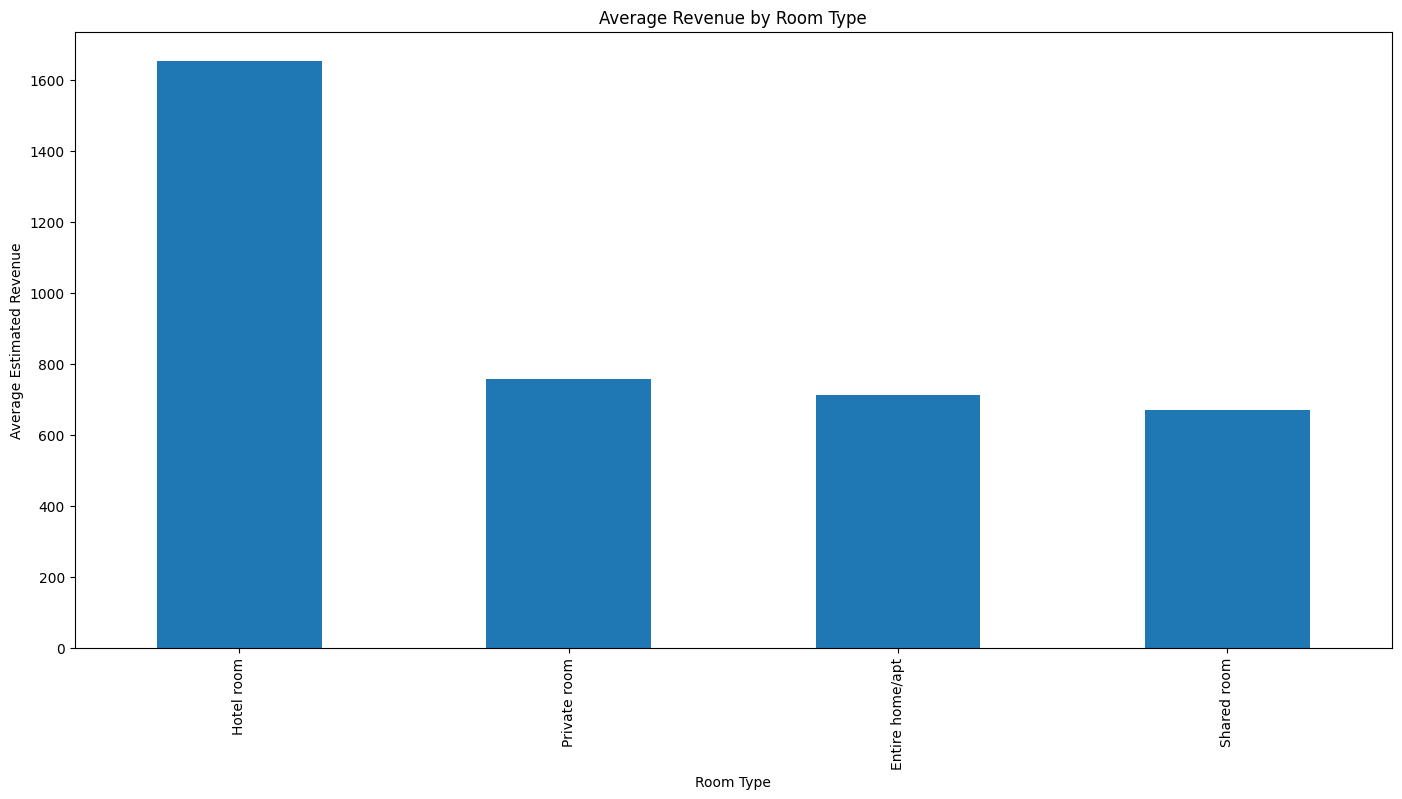

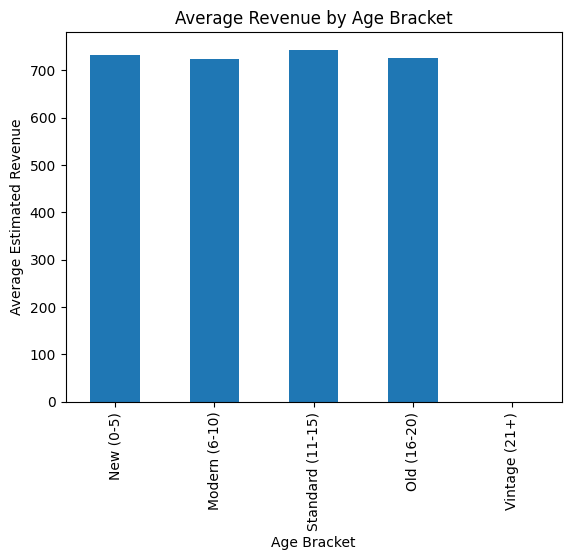

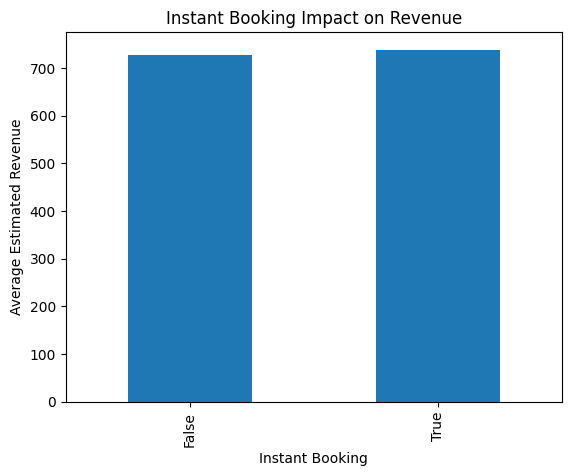

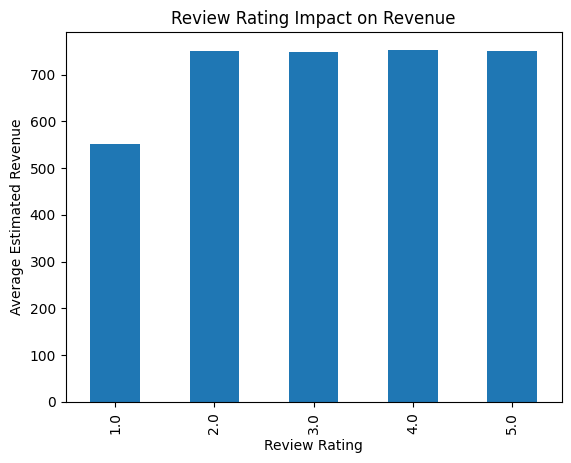

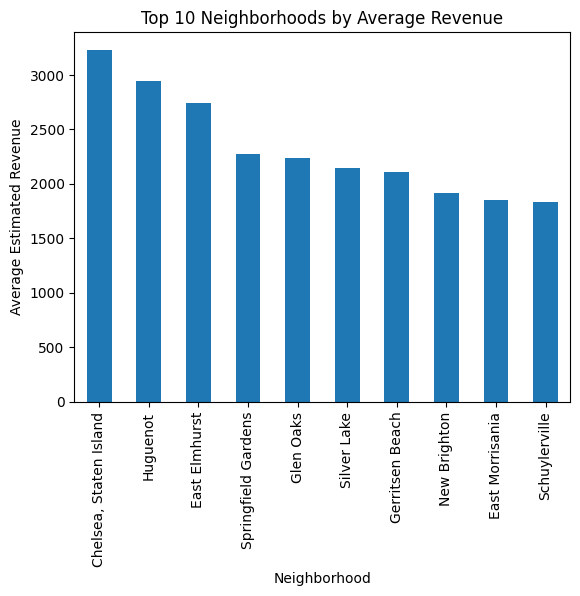

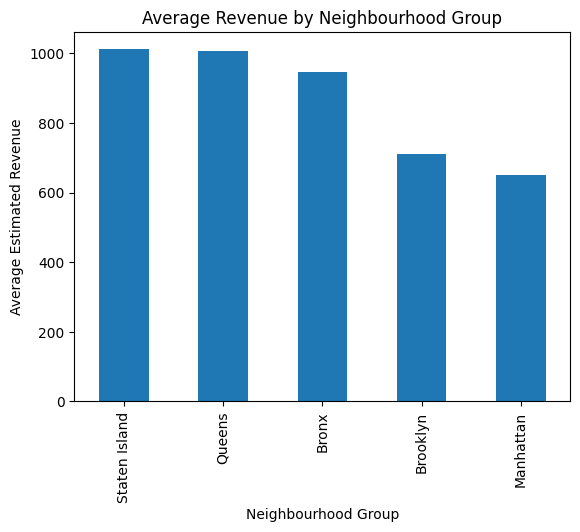

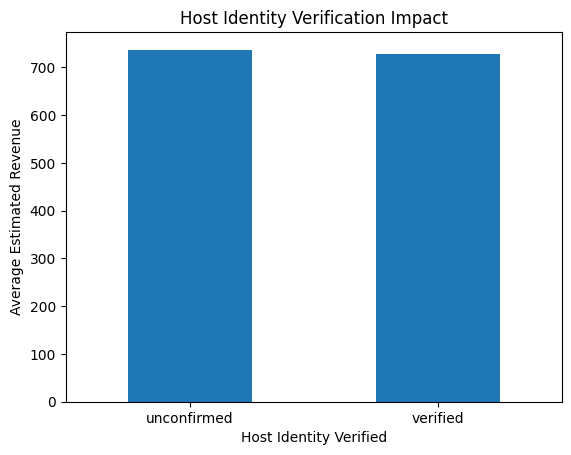

In [127]:
plt.figure(figsize=(17,8))
market_segmentation['est_monthly_revenue'].plot(kind='bar')
plt.title('Average Revenue by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Estimated Revenue')
plt.show()


age_revenue_impact.plot(kind='bar')
plt.title('Average Revenue by Age Bracket')
plt.xlabel('Age Bracket')
plt.ylabel('Average Estimated Revenue')
plt.show()

instant_book_impact.plot(kind='bar')
plt.title('Instant Booking Impact on Revenue')
plt.xlabel('Instant Booking')
plt.ylabel('Average Estimated Revenue')
plt.show()

rating_impact.plot(kind='bar')
plt.title('Review Rating Impact on Revenue')
plt.xlabel('Review Rating')
plt.ylabel('Average Estimated Revenue')
plt.show()

top_neighborhoods.plot(kind='bar')
plt.title('Top 10 Neighborhoods by Average Revenue')
plt.xlabel('Neighborhood')
plt.ylabel('Average Estimated Revenue')
plt.show()

location_analysis.plot(kind='bar')
plt.title('Average Revenue by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Estimated Revenue')
plt.show()

host_verify_impact.plot(kind='bar')
plt.title('Host Identity Verification Impact')
plt.xlabel('Host Identity Verified')
plt.ylabel('Average Estimated Revenue')
plt.xticks(rotation=0)
plt.savefig('host identity verification impact.png')
plt.show()

V1 shows that hotel room affect the listing revenue more than the others ,
V2 shows that all the categories in age bracket have a similar affect on the listing revenue ,
V3 the same goes for the instant booking ,
V4 shows that the higher review (2 or more) affect the listing revenue more the 1 review ,
V5 shows that Chelsa , Staten Island neighborhood affect the listing revenue more than the others ,
V6 shows that the group Staten Island and Queens affect the lising revenue more,
V7 the host veritfication categories have a similar affect on the listing revenue .


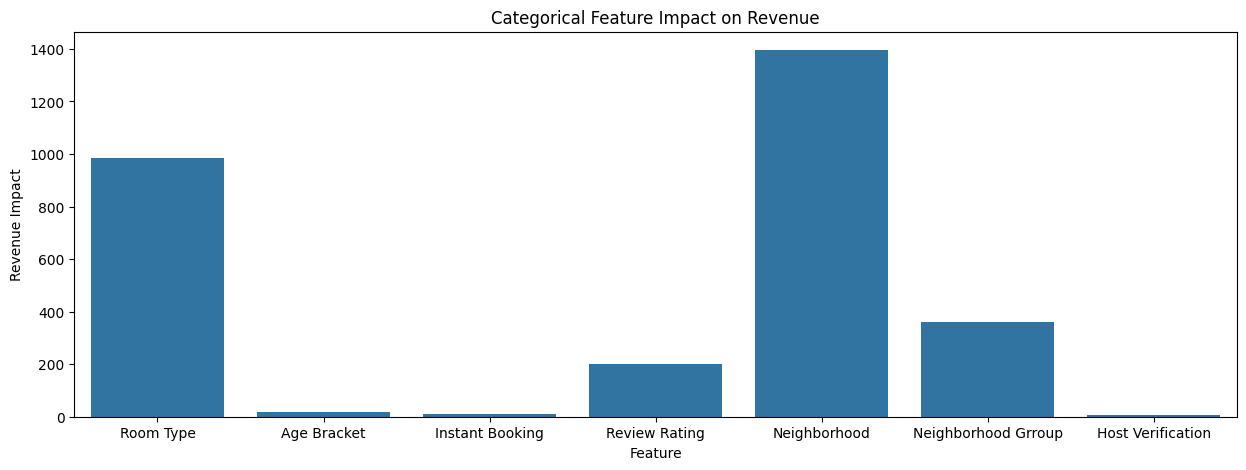

In [ ]:
feature_categorical_impact = pd.DataFrame({'Feature': ['Room Type','Age Bracket','Instant Booking','Review Rating','Neighborhood','Neighborhood Grroup','Host Verification' ],
                      'Revenue Impact': [market_segmentation['est_monthly_revenue'].max() - market_segmentation['est_monthly_revenue'].min(),
                       age_revenue_impact.max()-age_revenue_impact.min(),
                       instant_book_impact.max()-instant_book_impact.min(),
                       rating_impact.max()-rating_impact.min(),
                       top_neighborhoods.max()-top_neighborhoods.min(),
                       location_analysis.max()-location_analysis.min(),
                       host_verify_impact.max() - host_verify_impact.min() ] })

plt.figure(figsize=(15,5))
sns.barplot(data=feature_categorical_impact, x='Feature', y='Revenue Impact')
plt.title('Categorical Feature Impact on Revenue')
plt.savefig('categorical feature impact on revenue.png')
plt.show()

This visualization shows what categrical feature affetc the listing revenue more , which is the neighborhood and room type then neighborhood group the other don't affect that much

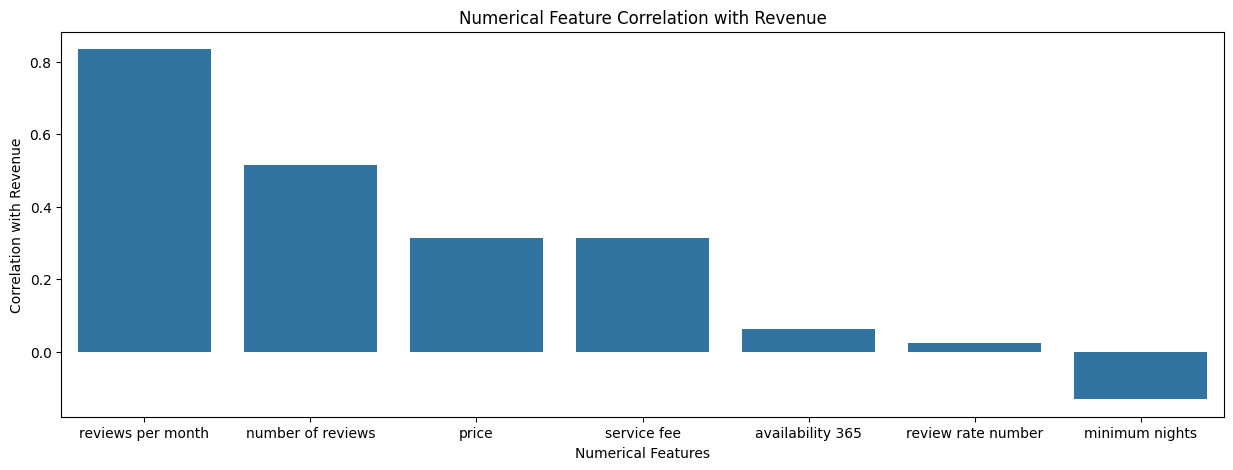

In [ ]:
numerical_corr = data[['price','service fee','minimum nights','number of reviews','reviews per month','review rate number','availability 365','est_monthly_revenue'
]].corr()['est_monthly_revenue'].drop('est_monthly_revenue')

numerical_corr = numerical_corr.sort_values(ascending=False)

plt.figure(figsize=(15,5))
sns.barplot(x=numerical_corr.index,
            y=numerical_corr.values)
plt.title('Numerical Feature Correlation with Revenue')
plt.ylabel('Correlation with Revenue')
plt.xlabel('Numerical Features')
plt.savefig('numerical feature correlation with revenue.png')
plt.show()

That visualization shows that the most numerical feature that affects the listing revenue is the reviews per month then the number of review .Also the minimum nights has a negative correlation with the listing revenue unlike the other that have a positive correlation ,which means when the minimum nights increase the rev

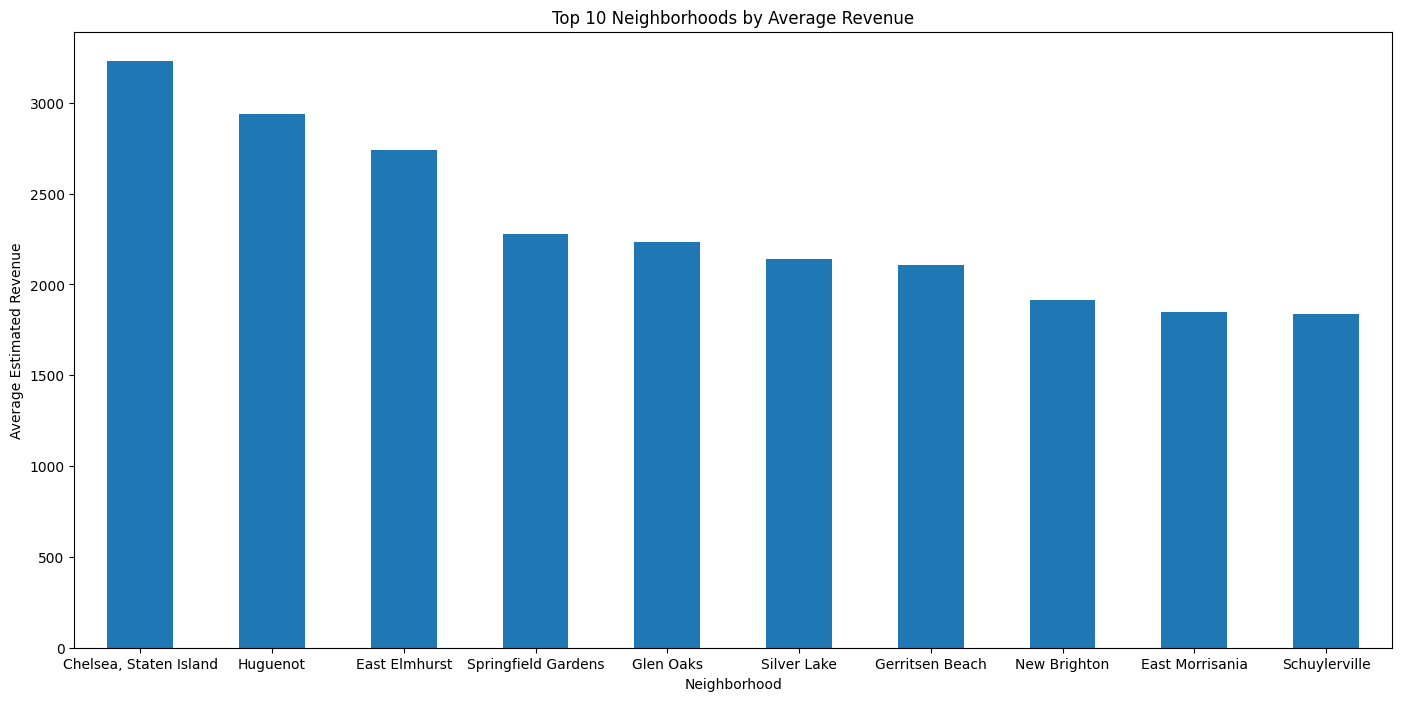

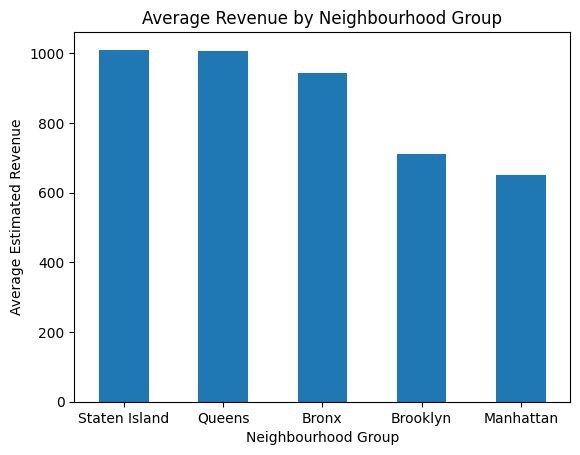

In [ ]:
plt.figure(figsize=(17,8))
top_neighborhoods.plot(kind='bar')
plt.title('Top 10 Neighborhoods by Average Revenue')
plt.xlabel('Neighborhood')
plt.ylabel('Average Estimated Revenue')
plt.xticks(rotation=0)
plt.savefig('top 10 neighborhoods by average revenue.png',dpi=300,bbox_inches='tight')
plt.show()

location_analysis.plot(kind='bar')
plt.title('Average Revenue by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Estimated Revenue')
plt.xticks(rotation=0)
plt.savefig('average revenue by neighbourhood group.png',dpi=300,bbox_inches='tight')
plt.show()


This answer our qusetion of Which neighborhoods
 offer the highest revenue potential?
as you can see from the top 10 nighborhood the Chelsea and Staten Islend offers the highest revenue when in the nighborhood group it's Staten Islend then the second highest is Queens

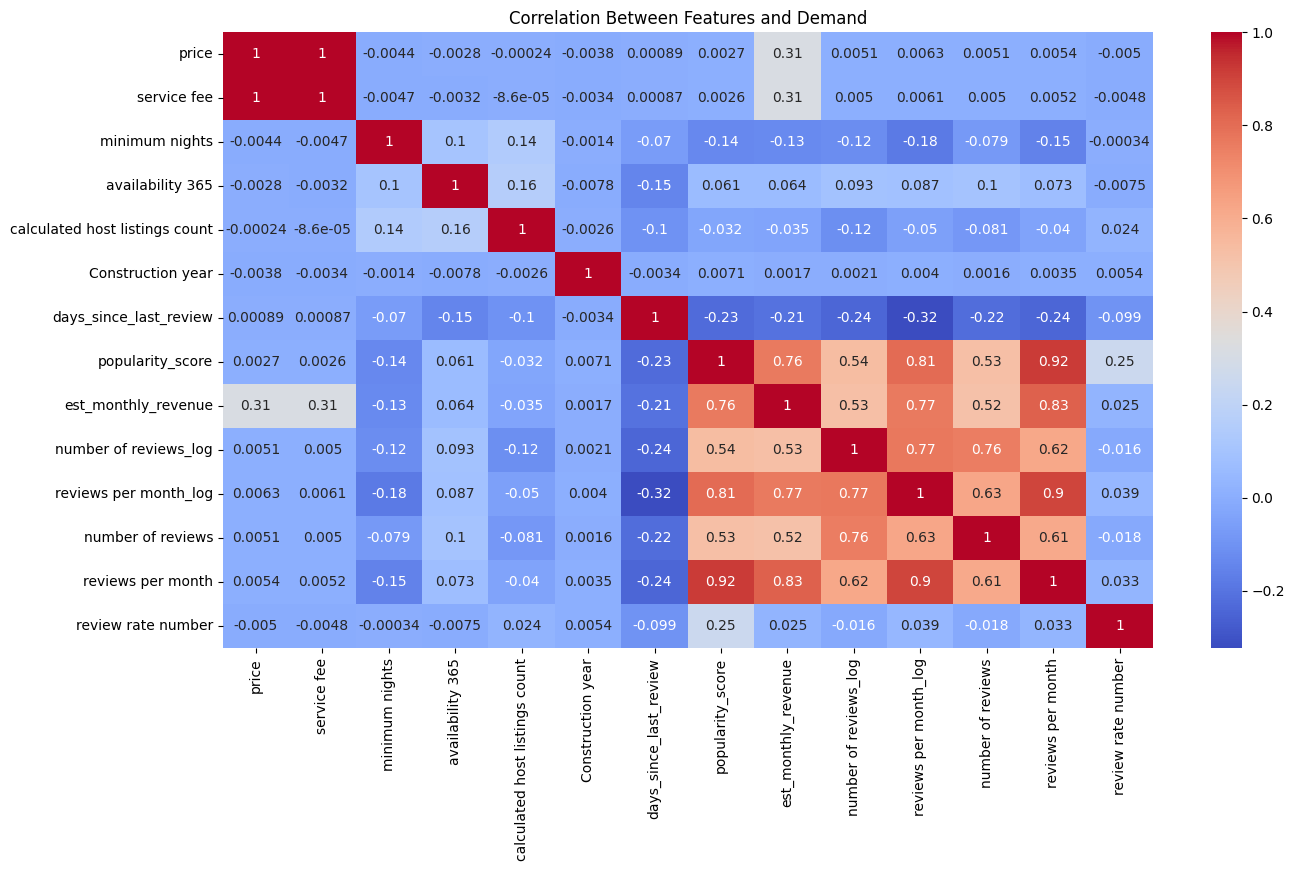

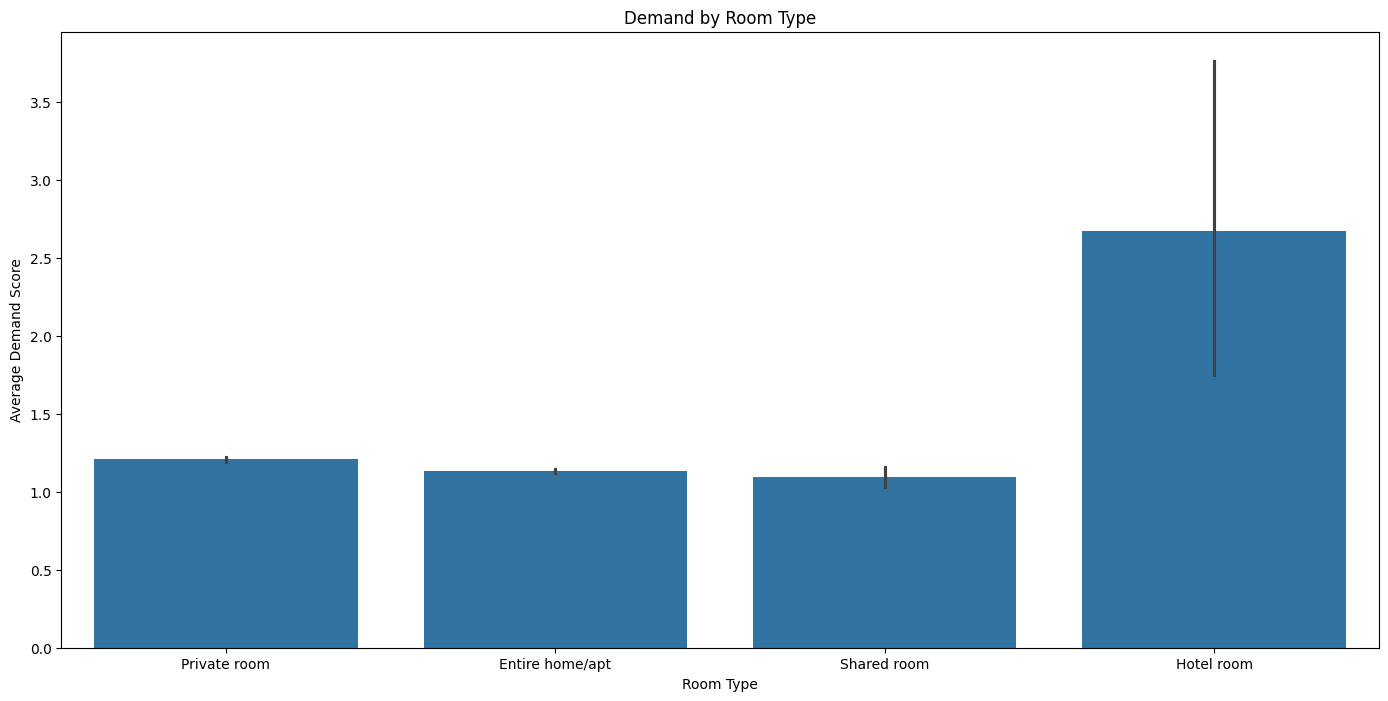

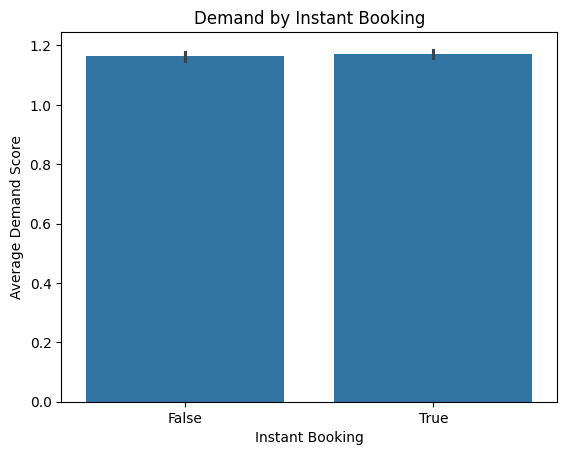

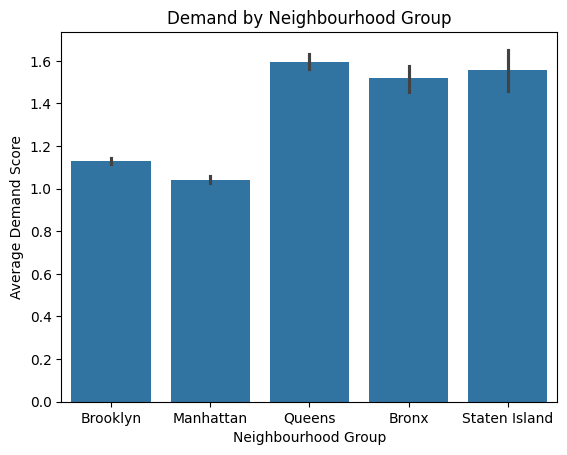

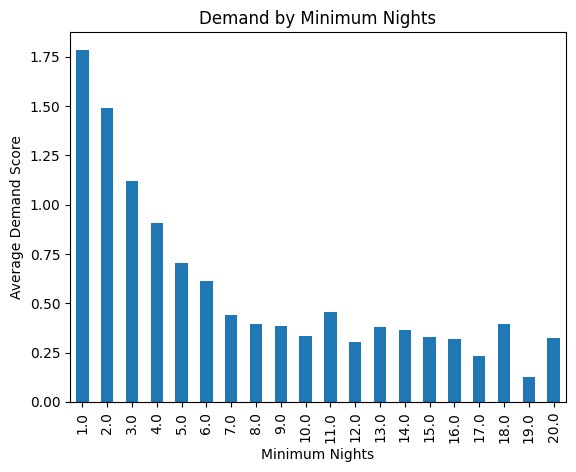

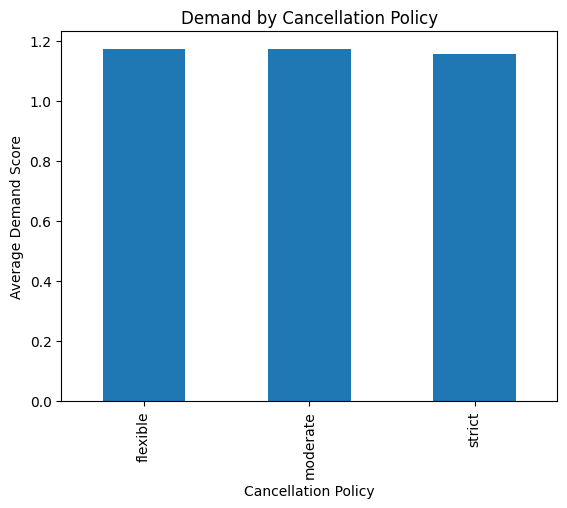

In [128]:
numerical_features = ['price','service fee','minimum nights','availability 365','calculated host listings count',
                      'Construction year','days_since_last_review','popularity_score','est_monthly_revenue',
                      'number of reviews_log','reviews per month_log','number of reviews','reviews per month','review rate number']
corr = data[numerical_features].corr()
plt.figure(figsize=(15,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Between Features and Demand')
plt.savefig('correlation between features and demand.png',dpi=300,bbox_inches='tight')
plt.show()

plt.figure(figsize=(17,8))
sns.barplot(data=data, x='room type',y='reviews per month')
plt.title('Demand by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Demand Score')
plt.savefig('demand by room type.png',dpi=300,bbox_inches='tight')
plt.show()

sns.barplot(data=data,x='instant_bookable', y='reviews per month')
plt.title('Demand by Instant Booking')
plt.xlabel('Instant Booking')
plt.ylabel('Average Demand Score')
plt.savefig('demand by instant booking.png',dpi=300,bbox_inches='tight')
plt.show()

sns.barplot(data=data, x='neighbourhood group', y='reviews per month')
plt.title('Demand by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Demand Score')
plt.savefig('demand by neighbourhood group.png',dpi=300,bbox_inches='tight')
plt.show()

demand_by_nights.plot(kind='bar')
plt.title('Demand by Minimum Nights')
plt.xlabel('Minimum Nights')
plt.ylabel('Average Demand Score')
plt.savefig('demand by minimum nights.png',dpi=300,bbox_inches='tight')
plt.show()

demand_by_cancellation.plot(kind='bar')
plt.title('Demand by Cancellation Policy')
plt.xlabel('Cancellation Policy')
plt.ylabel('Average Demand Score')
plt.savefig('demand by cancellation policy.png',dpi=300,bbox_inches='tight')
plt.show()

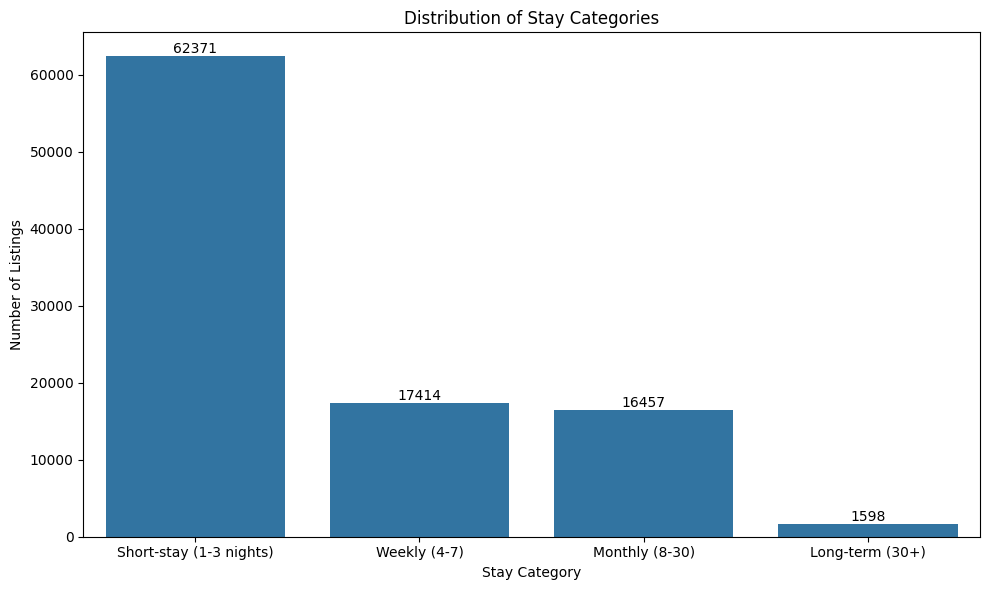

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count listings in each stay category
stay_counts = data['stay_category'].value_counts()

# Create figure
plt.figure(figsize=(10,6))

# Plot
ax = sns.countplot(
    data=data,
    x='stay_category',
    order=stay_counts.index
)

# Add title and labels
plt.title('Distribution of Stay Categories')
plt.xlabel('Stay Category')
plt.ylabel('Number of Listings')

# Add values above bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

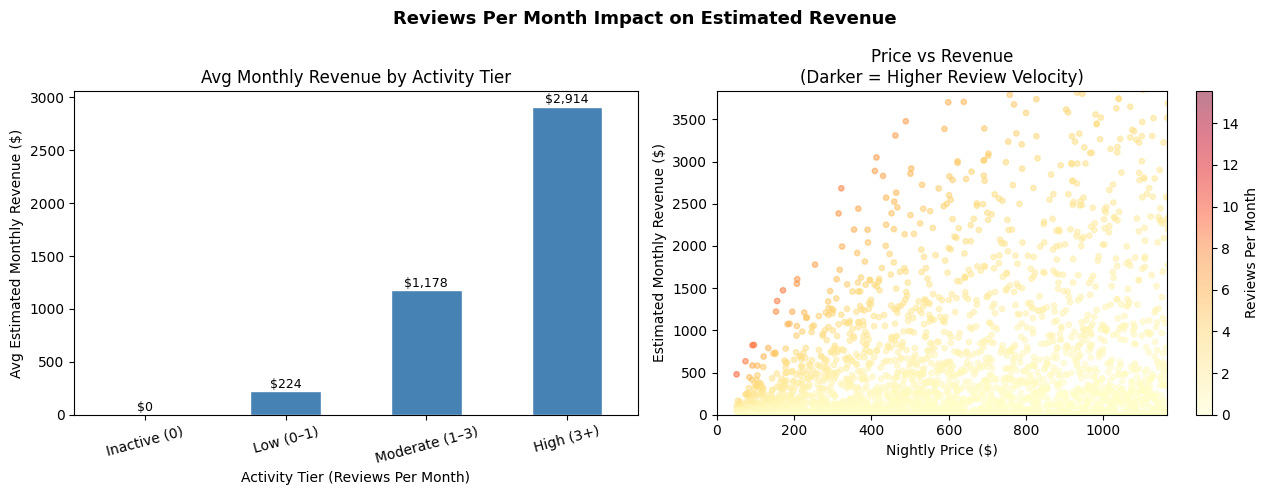

In [ ]:
# ── Reviews Per Month & Revenue Estimation ───────────────────

data['activity_tier'] = pd.cut(
    data['reviews per month'],
    bins=[-np.inf, 0, 1, 3, np.inf],
    labels=['Inactive (0)', 'Low (0–1)', 'Moderate (1–3)', 'High (3+)']
)

tier_summary = data.groupby('activity_tier', observed=True).agg(
    avg_revenue=('est_monthly_revenue', 'mean'),
    listing_count=('est_monthly_revenue', 'count')
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Reviews Per Month Impact on Estimated Revenue", fontsize=13, fontweight='bold')

# Chart 1: Avg revenue per activity tier
tier_summary['avg_revenue'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title("Avg Monthly Revenue by Activity Tier")
axes[0].set_xlabel("Activity Tier (Reviews Per Month)")
axes[0].set_ylabel("Avg Estimated Monthly Revenue ($)")
axes[0].tick_params(axis='x', rotation=15)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 f"${bar.get_height():,.0f}", ha='center', va='bottom', fontsize=9)

# Chart 2: Scatter — price vs revenue, colored by reviews per month
sample = data.sample(min(3000, len(data)), random_state=42)
sc = axes[1].scatter(
    sample['price'], sample['est_monthly_revenue'],
    c=sample['reviews per month'], cmap='YlOrRd', alpha=0.5, s=15
)
fig.colorbar(sc, ax=axes[1], label='Reviews Per Month')
axes[1].set_title("Price vs Revenue\n(Darker = Higher Review Velocity)")
axes[1].set_xlabel("Nightly Price ($)")
axes[1].set_ylabel("Estimated Monthly Revenue ($)")
axes[1].set_xlim(0, data['price'].quantile(0.97))
axes[1].set_ylim(0, data['est_monthly_revenue'].quantile(0.97))

plt.tight_layout()
plt.show()

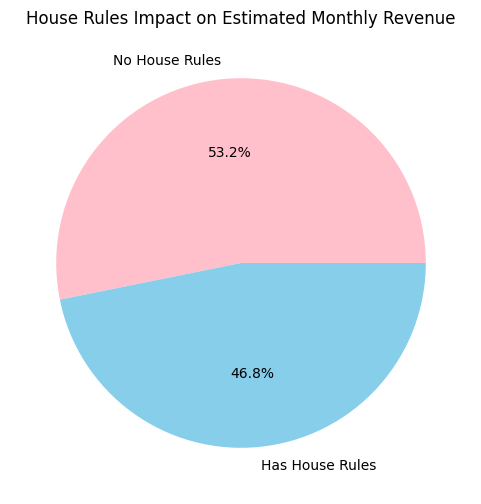

In [ ]:
# Impact of House Rules on Estimated Monthly Revenue
house_rules_impact = data.groupby('has_house_rules')['est_monthly_revenue'].mean()
house_rules_impact.index = ['No House Rules', 'Has House Rules']

plt.figure(figsize=(6, 6))
plt.pie(house_rules_impact, labels=house_rules_impact.index, autopct='%1.1f%%',colors=['pink','skyblue'])
plt.title('House Rules Impact on Estimated Monthly Revenue')
plt.show()


What features are associated with higher demand (bookings)?we can say that the review per month and number of reviews gives a higher demand
So in the heatmap you can see that the est monthly revenue, the popularity score , review per month_ log and nimber of review_log have a high effect on the demand .
The room type (hotel room) , nighborhood group (Staten Island and Queens) and minimum nights (1 and 2) have a high affect on the demand .

When the instant booking and cancellation policy categories have a similar effect on the demand

and  having house rules is associated with lower estimated revenue, possibly because strict rules discourage bookings